In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("dataset.csv", index_col=0)
print(df.shape)
df.head()

(114000, 20)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [2]:
# Check data types
df.dtypes

# Check missing values
df.isnull().sum()

# Basic stats
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [3]:
# Drop the 3 rows with missing values
df.dropna(inplace=True)

# Remove duplicate tracks (same track_id)
df.drop_duplicates(subset='track_id', inplace=True)

# Convert duration from milliseconds to seconds (more readable)
df['duration_sec'] = df['duration_ms'] / 1000

# Convert explicit to int (True=1, False=0) for ML later
df['explicit'] = df['explicit'].astype(int)

print("Clean shape:", df.shape)

Clean shape: (89740, 21)


In [4]:
# duration_ms has a max of 5.2 million ms = 87 minutes! Filter those out
df = df[df['duration_ms'] < 600000]  # keep songs under 10 min

# tempo = 0 is invalid
df = df[df['tempo'] > 0]

print("Final shape:", df.shape)

Final shape: (89035, 21)


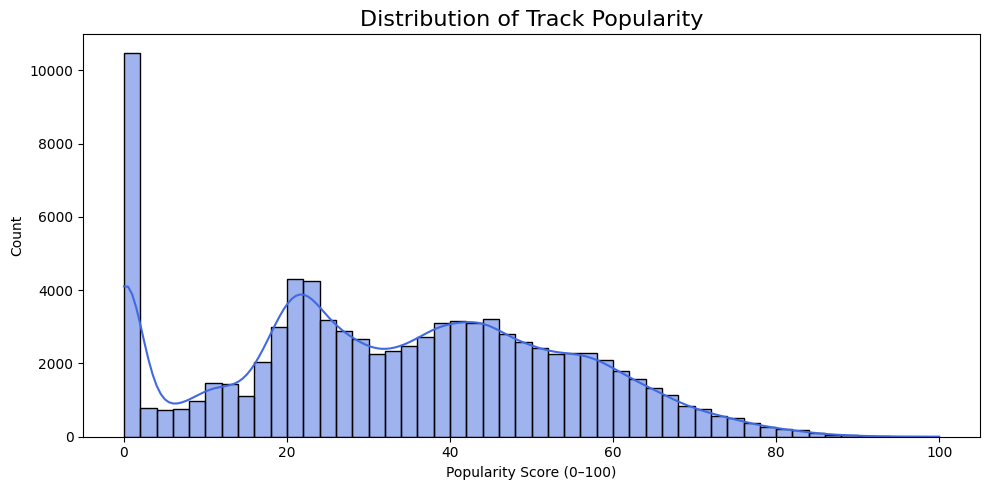

In [5]:
plt.figure(figsize=(10, 5))

sns.histplot(df['popularity'], bins=50, kde=True, color='royalblue')

plt.title('Distribution of Track Popularity', fontsize=16)
plt.xlabel('Popularity Score (0–100)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

C:\Users\amand\AppData\Local\Temp\ipykernel_11700\3887023633.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')


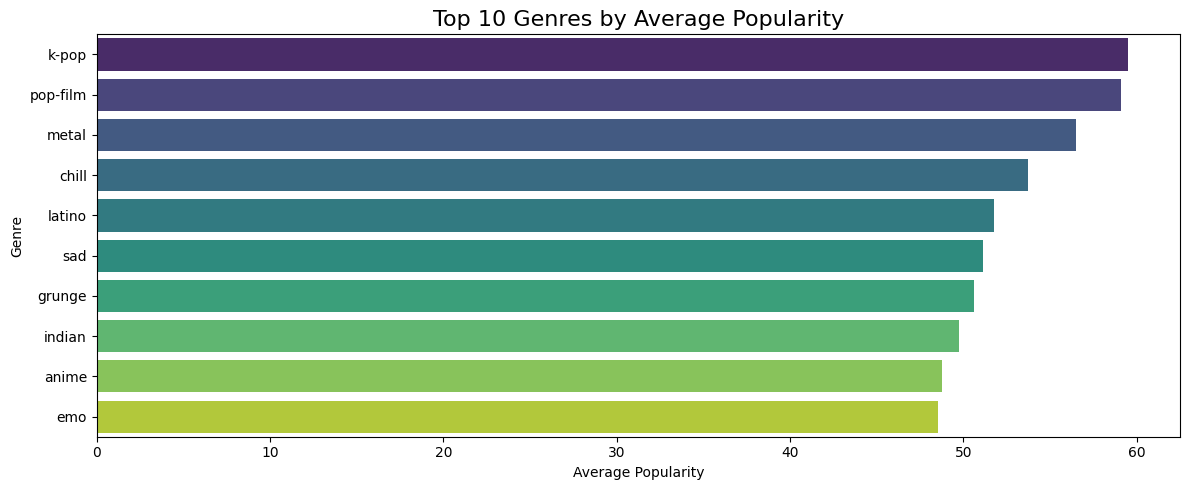

In [6]:
top_genres = (df.groupby('track_genre')['popularity']
                .mean()
                .sort_values(ascending=False)
                .head(10))

plt.figure(figsize=(12, 5))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')

plt.title('Top 10 Genres by Average Popularity', fontsize=16)
plt.xlabel('Average Popularity')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

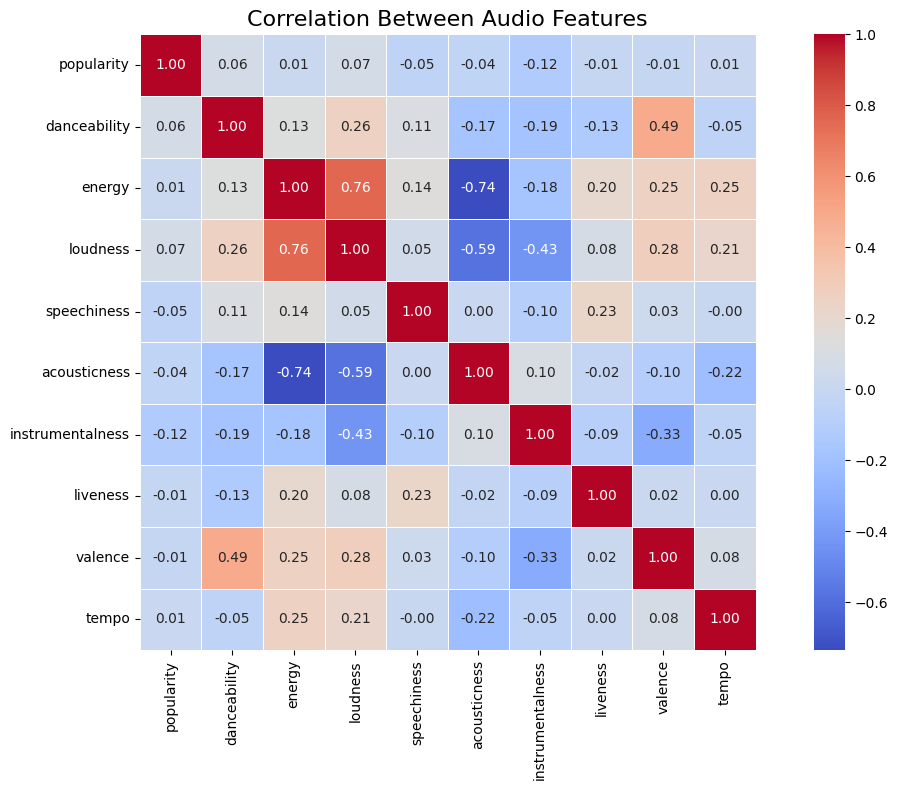

In [7]:
audio_features = ['popularity', 'danceability', 'energy', 'loudness',
                  'speechiness', 'acousticness', 'instrumentalness',
                  'liveness', 'valence', 'tempo']

plt.figure(figsize=(12, 8))
corr = df[audio_features].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)

plt.title('Correlation Between Audio Features', fontsize=16)
plt.tight_layout()
plt.show()

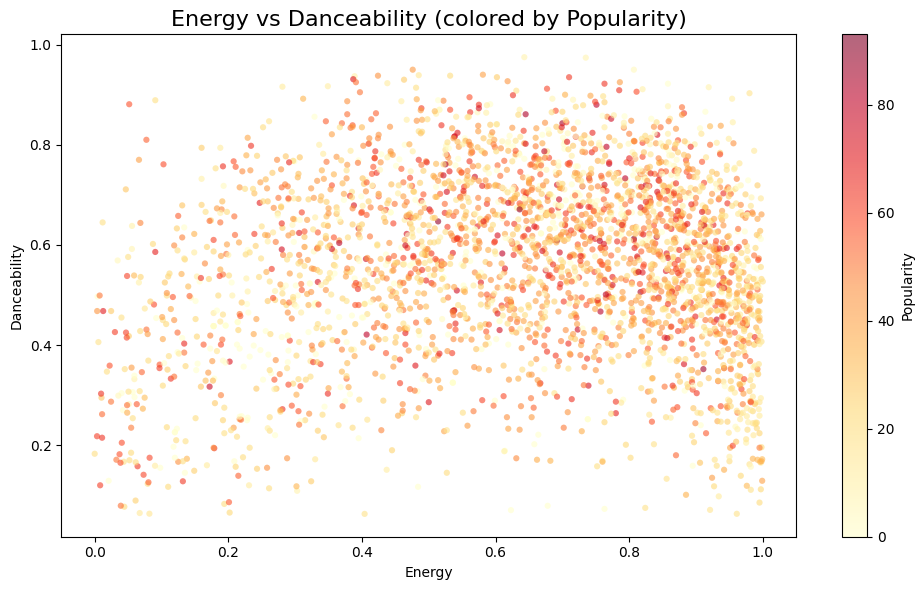

In [8]:
sample = df.sample(3000, random_state=42)  # sample so it's not too slow

plt.figure(figsize=(10, 6))
scatter = plt.scatter(sample['energy'], sample['danceability'],
                      c=sample['popularity'], cmap='YlOrRd',
                      alpha=0.6, edgecolors='none', s=20)

plt.colorbar(scatter, label='Popularity')
plt.title('Energy vs Danceability (colored by Popularity)', fontsize=16)
plt.xlabel('Energy')
plt.ylabel('Danceability')
plt.tight_layout()
plt.show()

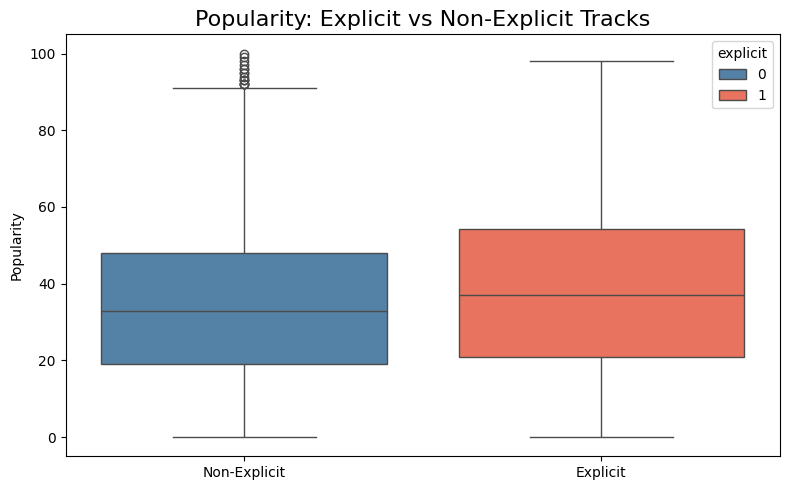

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='explicit', y='popularity', data=df,
            hue='explicit', palette={0: 'steelblue', 1: 'tomato'})

plt.xticks([0, 1], ['Non-Explicit', 'Explicit'])
plt.title('Popularity: Explicit vs Non-Explicit Tracks', fontsize=16)
plt.xlabel('')
plt.ylabel('Popularity')
plt.tight_layout()
plt.show()

In [11]:
# Summary stats for audio features grouped by genre
genre_stats = df.groupby('track_genre')[['popularity', 'danceability', 
                                          'energy', 'valence']].mean().round(3)

print(genre_stats.sort_values('popularity', ascending=False).head(10))

             popularity  danceability  energy  valence
track_genre                                           
k-pop            59.523         0.642   0.684    0.568
pop-film         59.097         0.592   0.600    0.529
metal            56.513         0.481   0.842    0.426
chill            53.739         0.666   0.430    0.408
latino           51.789         0.755   0.712    0.622
sad              51.110         0.702   0.479    0.440
grunge           50.587         0.455   0.805    0.401
indian           49.765         0.586   0.555    0.448
anime            48.777         0.538   0.674    0.435
emo              48.517         0.601   0.668    0.441


In [12]:
from scipy import stats

explicit     = df[df['explicit'] == 1]['popularity']
non_explicit = df[df['explicit'] == 0]['popularity']

t_stat, p_value = stats.ttest_ind(explicit, non_explicit)

print(f"Explicit mean popularity:     {explicit.mean():.2f}")
print(f"Non-Explicit mean popularity: {non_explicit.mean():.2f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_value:.4f}")

if p_value < 0.05:
    print("✅ Statistically significant difference!")
else:
    print("❌ No statistically significant difference.")

Explicit mean popularity:     36.92
Non-Explicit mean popularity: 32.90
T-statistic: 16.3534
P-value:     0.0000
✅ Statistically significant difference!


In [13]:
# Which features correlate most with popularity?
audio_features = ['danceability', 'energy', 'loudness', 'speechiness',
                  'acousticness', 'instrumentalness', 'liveness', 
                  'valence', 'tempo', 'duration_sec']

correlations = df[audio_features].corrwith(df['popularity']).sort_values(ascending=False)

print("Correlation with Popularity:")
print(correlations.round(4))

Correlation with Popularity:
loudness            0.0701
danceability        0.0648
energy              0.0127
tempo               0.0076
duration_sec       -0.0074
valence            -0.0138
liveness           -0.0144
acousticness       -0.0383
speechiness        -0.0467
instrumentalness   -0.1250
dtype: float64


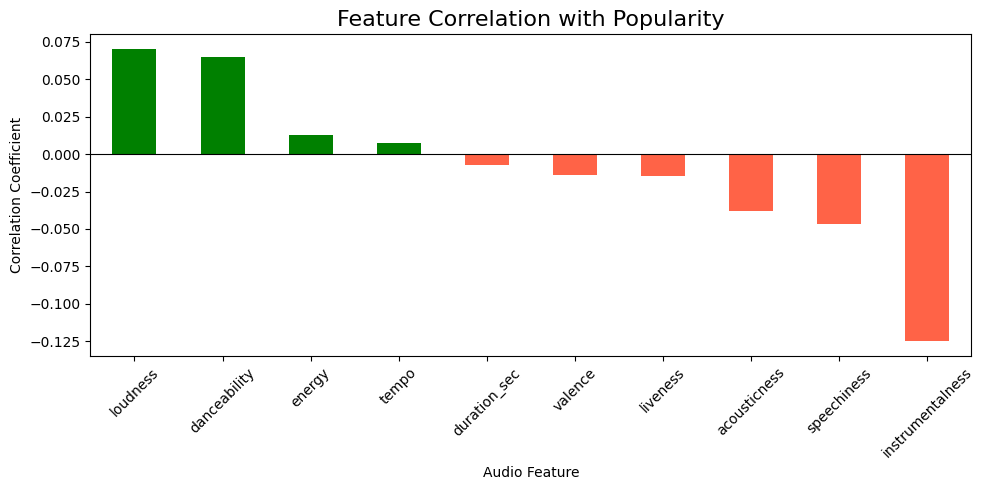

In [14]:
plt.figure(figsize=(10, 5))
correlations.plot(kind='bar', color=['green' if x > 0 else 'tomato' 
                                      for x in correlations])

plt.title('Feature Correlation with Popularity', fontsize=16)
plt.xlabel('Audio Feature')
plt.ylabel('Correlation Coefficient')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
def find_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    return len(outliers)

for feat in ['popularity', 'tempo', 'loudness', 'duration_sec']:
    print(f"{feat}: {find_outliers(feat)} outliers")

popularity: 11 outliers
tempo: 368 outliers
loudness: 4899 outliers
duration_sec: 3856 outliers


In [16]:
print("=" * 45)
print("KEY INSIGHTS")
print("=" * 45)
print(f"Most popular genre:    {genre_stats['popularity'].idxmax()}")
print(f"Most danceable genre:  {genre_stats['danceability'].idxmax()}")
print(f"Most energetic genre:  {genre_stats['energy'].idxmax()}")
print(f"Happiest genre:        {genre_stats['valence'].idxmax()}")
print(f"Top correlated feat:   {correlations.idxmax()}")
print(f"Least correlated feat: {correlations.idxmin()}")

KEY INSIGHTS
Most popular genre:    k-pop
Most danceable genre:  kids
Most energetic genre:  death-metal
Happiest genre:        salsa
Top correlated feat:   loudness
Least correlated feat: instrumentalness


In [17]:
# Define "popular" as popularity score above 50
df['is_popular'] = (df['popularity'] >= 50).astype(int)

print(df['is_popular'].value_counts())
print(df['is_popular'].value_counts(normalize=True).round(3))

is_popular
0    67881
1    21154
Name: count, dtype: int64
is_popular
0    0.762
1    0.238
Name: proportion, dtype: float64


In [19]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------------ --------------------------- 2.6/8.1 MB 16.6 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.1 MB 15.5 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.1 MB 15.2 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 13.4 MB/s  0:00:00

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -----------------

In [20]:
!conda install scikit-learn -y

'conda' is not recognized as an internal or external command,
operable program or batch file.


In [22]:
import sklearn
print(sklearn.__version__)

1.8.0


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

features = ['danceability', 'energy', 'loudness', 'speechiness',
            'acousticness', 'instrumentalness', 'liveness',
            'valence', 'tempo', 'duration_sec', 'explicit']

X = df[features]
y = df['is_popular']

# Split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)

Train size: (71228, 11)
Test size:  (17807, 11)


In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print("Model trained! ✅")

Model trained! ✅


In [25]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

           0       0.78      0.97      0.87     13576
           1       0.58      0.13      0.21      4231

    accuracy                           0.77     17807
   macro avg       0.68      0.55      0.54     17807
weighted avg       0.73      0.77      0.71     17807

ROC-AUC Score: 0.7093


C:\Users\amand\AppData\Local\Temp\ipykernel_11700\3277362314.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='magma')


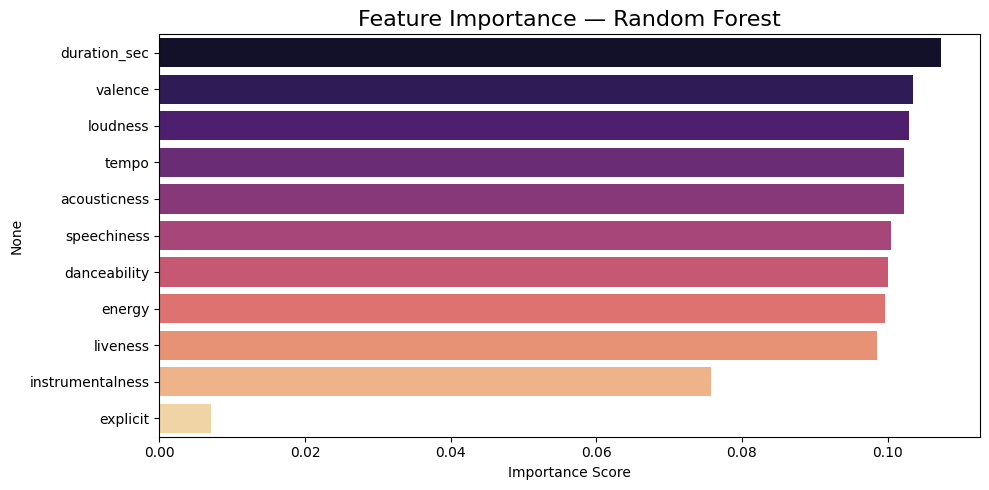

In [26]:
importances = pd.Series(rf.feature_importances_, index=features)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=importances.values, y=importances.index, palette='magma')

plt.title('Feature Importance — Random Forest', fontsize=16)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

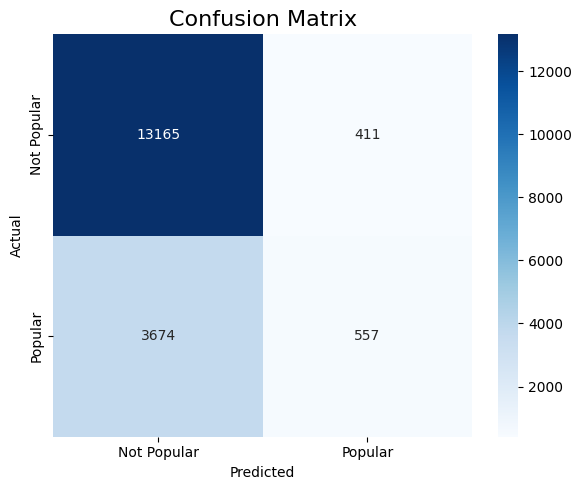

In [27]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Popular', 'Popular'],
            yticklabels=['Not Popular', 'Popular'])

plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()